In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print('Connected successfully')

Connected successfully


In [3]:
prices = pd.read_sql("""
    SELECT mp.date, e.name, e.country, e.region, e.category,
           mp.open, mp.high, mp.low, mp.close, mp.volume
    FROM market_prices mp
    JOIN exchanges e ON mp.exchange_id = e.exchange_id
    ORDER BY e.name, mp.date
""", engine, parse_dates=['date'])

derived = pd.read_sql("""
    SELECT dm.date, e.name, e.country, e.region,
           dm.daily_return, dm.rolling_vol_30, dm.rolling_vol_90,
           dm.rolling_ret_30, dm.drawdown
    FROM derived_metrics dm
    JOIN exchanges e ON dm.exchange_id = e.exchange_id
    ORDER BY e.name, dm.date
""", engine, parse_dates=['date'])

fx = pd.read_sql("""
    SELECT date, currency_pair, country, rate
    FROM fx_rates
    ORDER BY currency_pair, date
""", engine, parse_dates=['date'])

macro = pd.read_sql("""
    SELECT country, indicator_name, year, value
    FROM macro_indicators
    ORDER BY country, indicator_name, year
""", engine)

print(f'Prices: {len(prices)} rows')
print(f'Derived: {len(derived)} rows')
print(f'FX: {len(fx)} rows')
print(f'Macro: {len(macro)} rows')

Prices: 8844 rows
Derived: 8838 rows
FX: 6452 rows
Macro: 200 rows


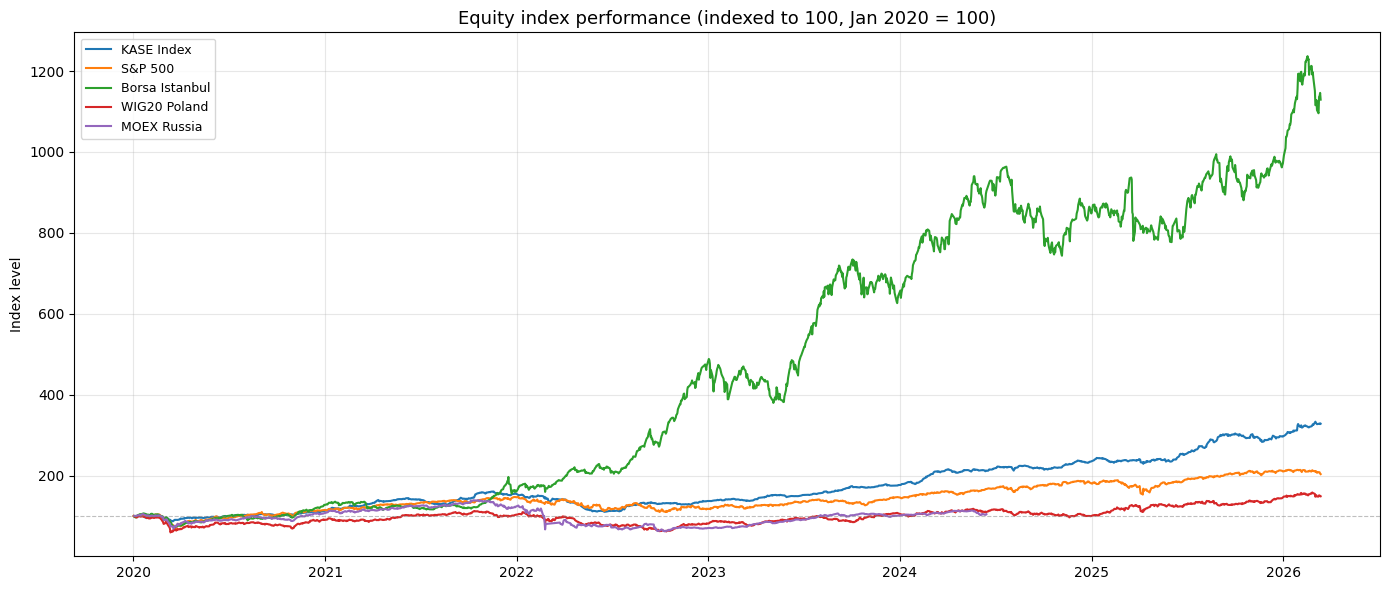

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))

equity_indices = ['KASE Index', 'S&P 500', 'Borsa Istanbul', 'WIG20 Poland', 'MOEX Russia']

for name in equity_indices:
    df = prices[prices['name'] == name].copy()
    df = df.set_index('date').sort_index()
    df['indexed'] = df['close'] / df['close'].iloc[0] * 100
    ax.plot(df.index, df['indexed'], label=name, linewidth=1.5)

ax.axhline(100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Equity index performance (indexed to 100, Jan 2020 = 100)', fontsize=13)
ax.set_ylabel('Index level')
ax.set_xlabel('')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('price_performance.png', dpi=150)
plt.show()

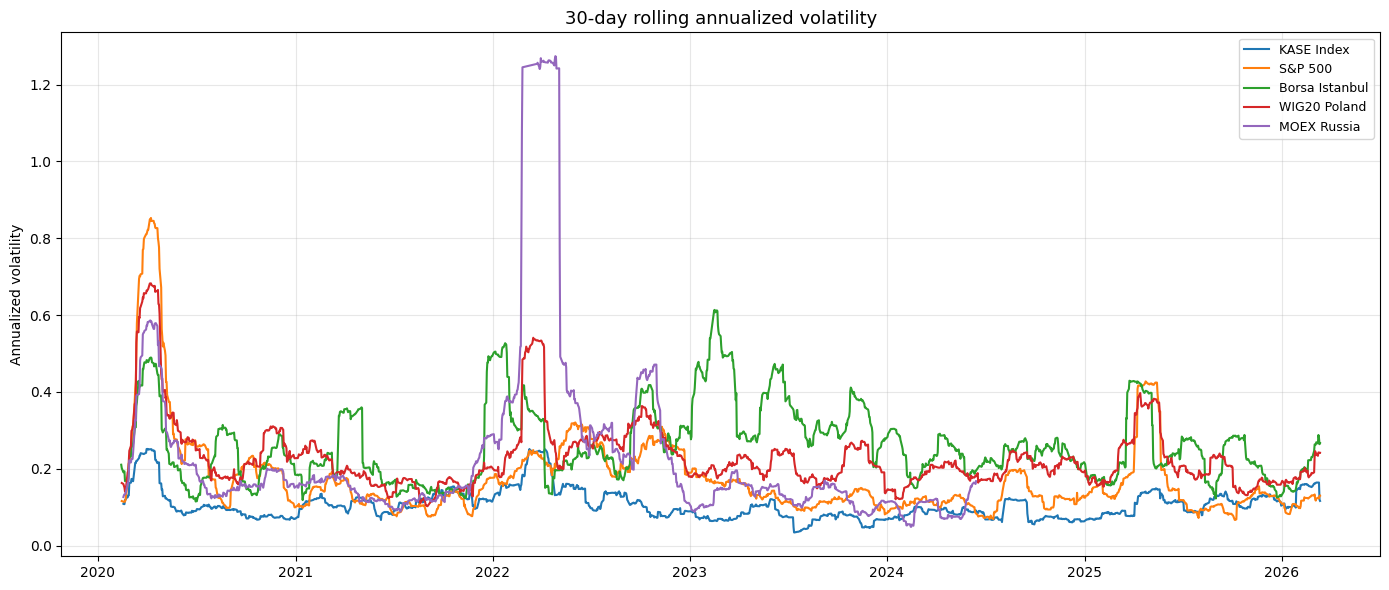

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

for name in equity_indices:
    df = derived[derived['name'] == name].copy()
    df = df.set_index('date').sort_index()
    ax.plot(df.index, df['rolling_vol_30'], label=name, linewidth=1.5)

ax.set_title('30-day rolling annualized volatility', fontsize=13)
ax.set_ylabel('Annualized volatility')
ax.set_xlabel('')
ax.legend(loc='upper right', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rolling_volatility.png', dpi=150)
plt.show()

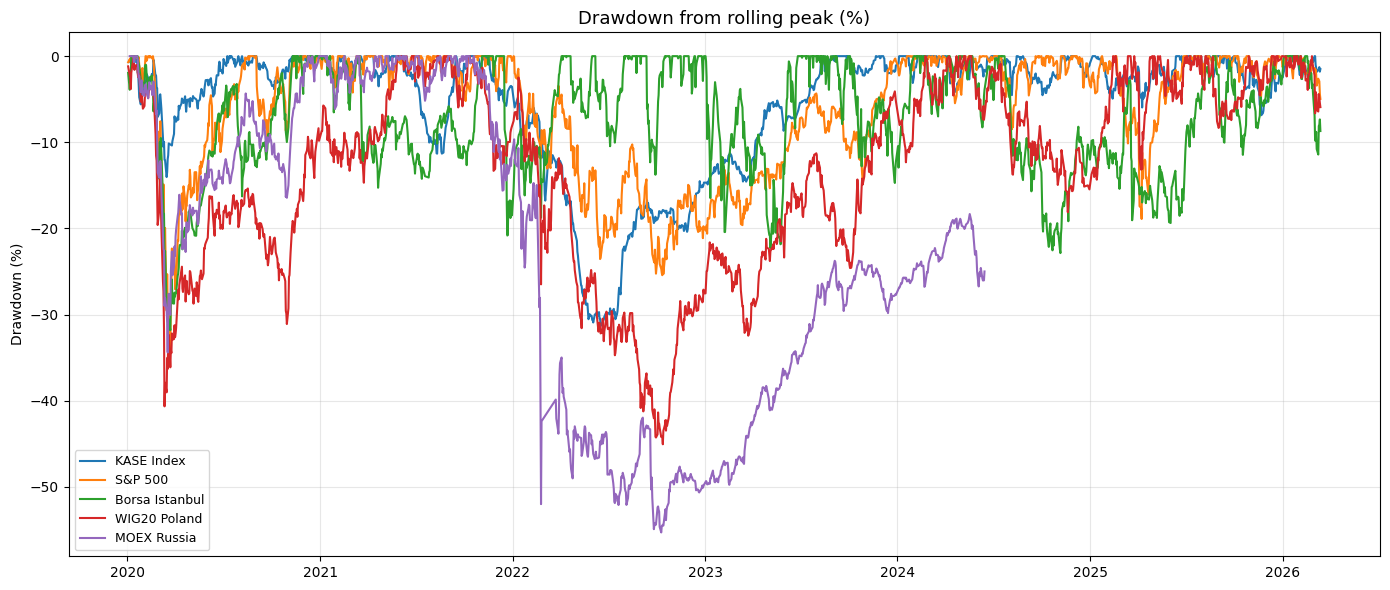

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

for name in equity_indices:
    df = derived[derived['name'] == name].copy()
    df = df.set_index('date').sort_index()
    ax.plot(df.index, df['drawdown'] * 100, label=name, linewidth=1.5)

ax.set_title('Drawdown from rolling peak (%)', fontsize=13)
ax.set_ylabel('Drawdown (%)')
ax.set_xlabel('')
ax.legend(loc='lower left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('drawdown.png', dpi=150)
plt.show()

## Data quality notes
- USD/RUB data contains artifacts post-2022 due to sanctions-related 
  liquidity gaps in Western data providers. MOEX data also stops at 
  mid-2024 for the same reason. These limitations are noted and do not 
  affect the core KASE analysis.
- Borsa Istanbul nominal returns reflect hyperinflationary conditions 
  in Turkey and should be interpreted alongside USD/TRY depreciation data.

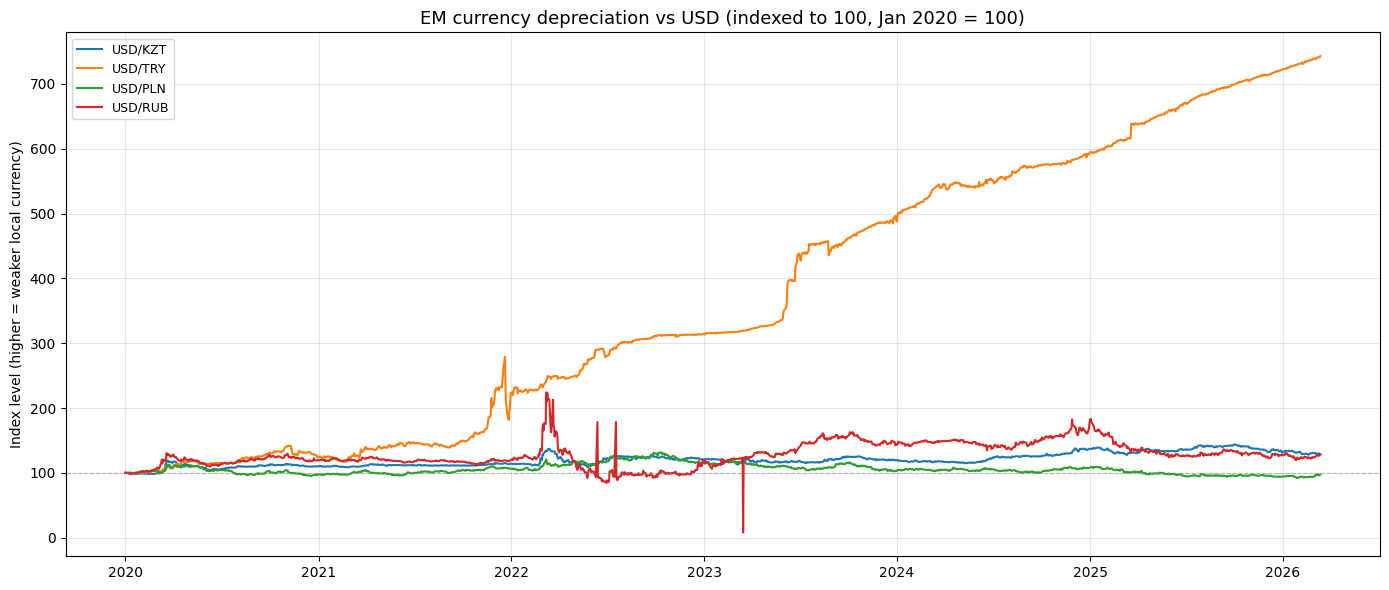

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

for pair in ['USD_KZT', 'USD_TRY', 'USD_PLN', 'USD_RUB']:
    df = fx[fx['currency_pair'] == pair].copy()
    df = df.set_index('date').sort_index()
    df['indexed'] = df['rate'] / df['rate'].iloc[0] * 100
    ax.plot(df.index, df['indexed'], label=pair.replace('_', '/'), linewidth=1.5)

ax.axhline(100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('EM currency depreciation vs USD (indexed to 100, Jan 2020 = 100)', fontsize=13)
ax.set_ylabel('Index level (higher = weaker local currency)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fx_performance.png', dpi=150)
plt.show()

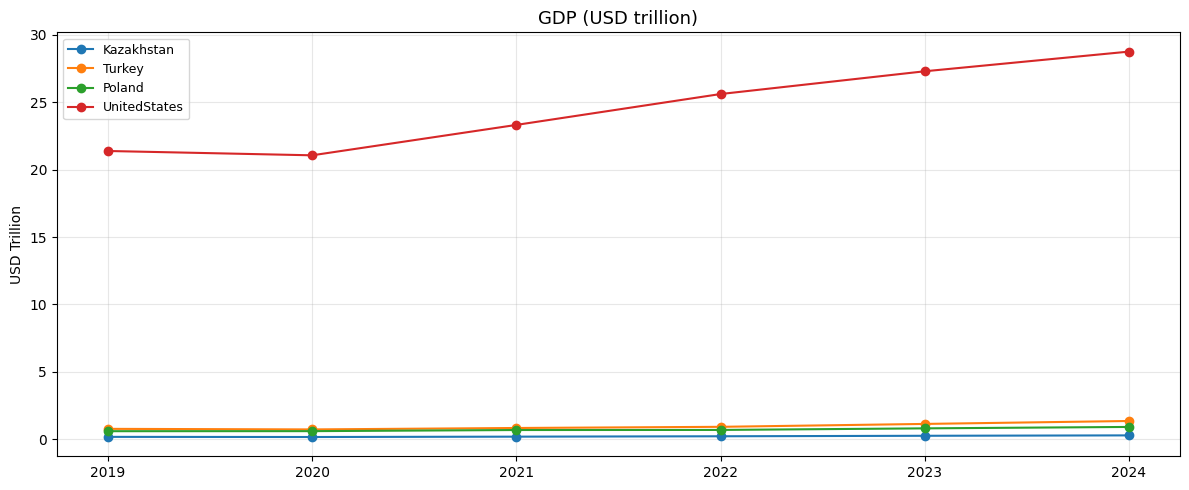

In [8]:
gdp = macro[macro['indicator_name'] == 'GDP (current USD)'].copy()
gdp = gdp[gdp['year'] >= 2019]

fig, ax = plt.subplots(figsize=(12, 5))

for country in ['Kazakhstan', 'Turkey', 'Poland', 'UnitedStates']:
    df = gdp[gdp['country'] == country].sort_values('year')
    ax.plot(df['year'], df['value'] / 1e12, marker='o', label=country, linewidth=1.5)

ax.set_title('GDP (USD trillion)', fontsize=13)
ax.set_ylabel('USD Trillion')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gdp_comparison.png', dpi=150)
plt.show()

In [9]:
summary = derived[derived['name'].isin(equity_indices)].groupby('name').agg(
    avg_daily_return  = ('daily_return',   'mean'),
    avg_vol_30        = ('rolling_vol_30', 'mean'),
    max_drawdown      = ('drawdown',       'min'),
    latest_vol        = ('rolling_vol_30', 'last'),
).reset_index()

summary['avg_daily_return'] = (summary['avg_daily_return'] * 100).round(4)
summary['avg_vol_30']       = (summary['avg_vol_30'] * 100).round(2)
summary['max_drawdown']     = (summary['max_drawdown'] * 100).round(2)
summary['latest_vol']       = (summary['latest_vol'] * 100).round(2)

summary.columns = ['Index', 'Avg daily return (%)', 'Avg vol 30d (%)', 
                   'Max drawdown (%)', 'Latest vol 30d (%)']
summary

,Index,Avg daily return (%),Avg vol 30d (%),Max drawdown (%),Latest vol 30d (%)
0,Borsa Istanbul,0.1723,26.12,-31.82,26.68
1,KASE Index,0.0806,10.54,-31.32,11.64
2,MOEX Russia,0.0229,21.93,-55.29,16.78
3,S&P 500,0.0542,17.53,-33.92,13.02
4,WIG20 Poland,0.0377,22.92,-45.05,24.17
